In [30]:
import pickle
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

In [31]:
# 1. Load your dataset
dataset = pd.read_csv("/content/kidney_disease_cleaned (1).csv")

In [32]:
dataset

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48,80,1.020,1,0.0,0.0,1.0,0,0,...,44.0,7800.0,5.200000,1.0,1.0,0.0,0,0.0,0.0,ckd
1,1,7,50,1.020,4,0.0,0.0,1.0,0,0,...,38.0,6000.0,4.734444,0.0,0.0,0.0,0,0.0,0.0,ckd
2,2,62,80,1.010,2,3.0,1.0,1.0,0,0,...,31.0,7500.0,4.734444,0.0,1.0,0.0,1,0.0,1.0,ckd
3,3,48,70,1.005,4,0.0,1.0,0.0,1,0,...,32.0,6700.0,3.900000,1.0,0.0,0.0,1,1.0,1.0,ckd
4,4,51,80,1.010,2,0.0,1.0,1.0,0,0,...,35.0,7300.0,4.600000,0.0,0.0,0.0,0,0.0,0.0,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55,80,1.020,0,0.0,1.0,1.0,0,0,...,47.0,6700.0,4.900000,0.0,0.0,0.0,0,0.0,0.0,notckd
396,396,42,70,1.025,0,0.0,1.0,1.0,0,0,...,54.0,7800.0,6.200000,0.0,0.0,0.0,0,0.0,0.0,notckd
397,397,12,80,1.020,0,0.0,1.0,1.0,0,0,...,49.0,6600.0,5.400000,0.0,0.0,0.0,0,0.0,0.0,notckd
398,398,17,60,1.025,0,0.0,1.0,1.0,0,0,...,51.0,7200.0,5.900000,0.0,0.0,0.0,0,0.0,0.0,notckd


In [33]:
# 2. Split features (X) and target (y)
X = dataset.drop("classification", axis=1)   # replace 'target_column' with your label column
y = dataset["classification"]

In [34]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [35]:
# Model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predictions
y_pred = gnb.predict(X_test)

# Evaluation
print("=== GaussianNB ===")
print("Accuracy:", accuracy_score(y_test, y_pred))

=== GaussianNB ===
Accuracy: 0.96


Classification Report:

              precision    recall  f1-score   support

         ckd       1.00      0.94      0.97        63
      notckd       0.90      1.00      0.95        37

    accuracy                           0.96       100
   macro avg       0.95      0.97      0.96       100
weighted avg       0.96      0.96      0.96       100



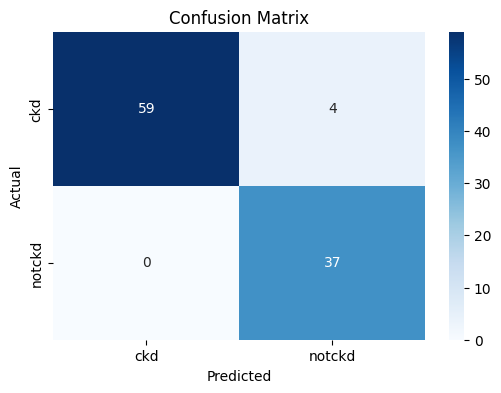

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

report = classification_report(y_test, y_pred)
print("Classification Report:\n")
print(report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=gnb.classes_, yticklabels=gnb.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [37]:
# 8. Save model using pickle
with open("gaussian_nb.pkl", "wb") as f:
    pickle.dump((gnb, label_encoder), f)   # save model + label encoder

print("\nModel saved as gaussian_nb.pkl")

# 9. Load model back
with open("gaussian_nb.pkl", "rb") as f:
    loaded_model, loaded_encoder = pickle.load(f)


Model saved as gaussian_nb.pkl
